# Diabetes Risk Factor Analysis
##**1. Purpose And Overview**

This project analyzes patient characteristics associated with diabetes outcomes using a diabetes outcomes using a diabetes risk factor dataset. The purpose is to demonstrate a reproducible data science workflow, including data validation, preparation, descriptive statistics, visualization, correlation analysis, inferential statistics, and logistic regression. The notebook is designed so that another data scientist can reproduce the analysis from the project repository without relying on the original analyst's local environment.

***** DATA SCIENCE DIRECTOR NOTE *****

This notebook will be shared with the data science team at one of our other clinical sites. They will not have access to your current computational environment or any undocumented setup steps.

Please prepare the notebook and supporting project files so that their team can obtain the repository, follow the documentation, execute the complete workflow, and reproduce the current analytical results without needing to contact you for additional instructions. The notebook should also be sufficiently documented and organized so that the receiving team can use the workflow as a template for conducting a similar analysis with patient data from their own clinical site.

I have also left several notes throughout the notebook identifying changes or additions that need to be addressed before the project is shared.

---

## **2. Setup and Environment**

### Google Colab
- Open 'Diabetes_Risk_Factor_Analysis.ipynb' in Google colab from the GitHub repository
- Sign in Google Colab with a valid Google account
- Ensure that the notebook has access to the internet so the dataset can be loaded from Github
- Run the notebook cells from top to bottom by clicking on 'Run all'
- No local copy of the CSV file is required because the notebook loads the dataset from the project's Github repository.

### Python Libraries
The notebook uses the following Python packages:

- 'pandas' - data loading, cleaning, and analysis
- 'numpy' - numerical operations
- 'matplotlib' - data visualization
- 'scipy' - statistical testing
- 'statsmodels' - logistic regression
Package versions used for this project are documented in 'requirements.txt'

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import statsmodels.api as sm

print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
scipy: 1.16.3
statsmodels: 0.15.0


## **3. Data Source**

The project uses the file 'Example Dataset_Diabetes.csv', which is included directly in this repository.

The dataset contains 768 observations and 9 variables representing patient characteristics and diabetes outcome. The variables include:

- 'Pregnancies'
- 'Glucose'
- 'D_BP'
- 'Skin_Thickness'
- 'Insulin'
- 'BMI'
- 'Pedigree'
- 'Age'
- 'Outcome'

The notebook loads the dataset directly from the project's GitHub repository using the raw CSV file URL. This helps avoid dependence on a local file path or the original analyst's computational environment.

### ***3.1 Data Loading***

The diabetes dataset is loaded from the project's GitHub repository using the raw CSD file URL. Loading the dataset from the repository avoides dependence on a local file path or the original analyst's computational environment.

The first five rows are displayed to confirm that the dataset was loaded successfully and to provide an initial view of the variable and their values.

The dataset should remain available at the documented GitHub locaation for the notebook to reporduce the analysis.

In [9]:
url = "https://raw.githubusercontent.com/Vannie2002/HDS_HSE751/main/Example%20Dataset_Diabetes.csv"
df = pd.read_csv(url)
df.head()


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


***** DATA SCIENCE DIRECTOR NOTE *****

The current data-loading process appears to depend on the original analyst's environment. Please revise it so another user can successfully load the dataset by following the project instructions.

Also make the data provenance documentation sufficiently specific for the receiving team to understand the origin and role of the dataset used in this project.

## **4. Initial Data Review**

Before preparing the data for analysis, the dataset is reviewed to confirm its structure, variable types, completenss, and basic distributions. This initial data review helps identify potential data-quality issues that may need to be addressed before statistical analysis.

The following checks are performed:
- **Dataset dimensions:** confirms the number of observations and variables
- **Variable names and data types:** verifies that variables were imported with the expected names and approrpiate data types
- **Missing values:** identifies observations with missing values recorded as 'NaN'

These inspections help determine whether additional data preparation or cleaning is needed before conducting the analysis.

In [10]:
# check dimensions of the dataset
df.shape

# review variable names and data types
df.info()

# check for missing values
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pregnancies     768 non-null    int64  
 1   Glucose         768 non-null    int64  
 2   D_BP            768 non-null    int64  
 3   Skin_Thickness  768 non-null    int64  
 4   Insulin         768 non-null    int64  
 5   BMI             768 non-null    float64
 6   Pedigree        768 non-null    float64
 7   Age             768 non-null    int64  
 8   Outcome         768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
D_BP,0
Skin_Thickness,0
Insulin,0
BMI,0
Pedigree,0
Age,0
Outcome,0


### ***4.1 Additional Data Validation***

Additional checks are performed to verify that the expected dataset has been loaded before data preparation and analysis. These inspections confirm that the expected variables are present, identify duplicate observations, verify the coding of the binary outcome variable, and identify zero values that may require further investigation.

The expected-column check compares the variables in the dataset with the variables required for this analysis. If any expected variables are missing, the validation check will identify them before the analysis continues.

The zero-value check is particularly important because some clinical measurements cannot reasonably have a value of zero. These values will be investigated during data preparation rather than automatically treated as missing at this stage.

In [11]:
# confirm the expected variables are present

expected_columns = ["Pregnancies", "Glucose", "D_BP", "Skin_Thickness",
    "Insulin", "BMI", "Pedigree", "Age", "Outcome"]

missing_columns = set(expected_columns) - set(df.columns)

if missing_columns:
    print("Validation failed. Missing columns:", missing_columns)
else:
    print("Validation passed. All expected columns are present.")

Validation passed. All expected columns are present.


In [12]:
# check for duplicate observations
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
# check unique values of the outcome variable
print("Outcome values:", sorted(df["Outcome"].unique()))

Outcome values: [np.int64(0), np.int64(1)]


In [14]:
# check the number of zero values in each variable

print("Zero values by variable:")
print((df == 0).sum())

Zero values by variable:
Pregnancies       111
Glucose             5
D_BP               35
Skin_Thickness    227
Insulin           374
BMI                11
Pedigree            0
Age                 0
Outcome           500
dtype: int64


## **5. Descriptive Statistics**

Descriptive statistics are used to summarize the distributions of the clinical and demographica variables in the diabetes dataset. The 'describe()' function provides the count, mean, standard deviation, minimum, quartiles, and maximum for each numeric variable. These descriptive statistics provide an initial understanding of the characteristics and variability of the study population. They also help identify variables with unusual ranges or potentially problematic values that should be investigated during data validation and preparation. For example, several clinical variables have minimum values of zero, which may require further review because zero may not represent a plausible measurement for those variables.

For continuous variables such as **Glucose, D_BP, Skin_Thickness, Insulin, BMI, Pedigree, and Age**, the mean provides a measure of the avaerage value in the study population, while the standard deviation describes the variablity of observations around the mean.

The **sample mean** is calculated as:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

where

- $s$ = sample standard deviation
- $x_i$ = value for each observation
- $\bar{x}$ = sample mean
- $n$ = total number of observations

-----

The **sample standard deviation** is calcualted as:

$$
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

where:

- $s$ = sample standard deviation
- $x_i$ = value for each observation
- $\bar{x}$ = sample mean
- $n$ = total number of observations

For example, the dataset has a mean **Glucose** value of approximately **120.9** with a standard deviation of approximately **32.0**, indicating that glucose measurements vary substantially around the sample mean. The mean **BMI** is approximately **32.0** with a standard deviation of approximately **7.9**, while the mean **Age** is approximately **33.2** years with a standard deviation of approximately **11.8** years.

In other words, a smaller standard deviation indicates that observations are more closely clustered around the mean, while a larger standard deviation indicates greater variability.

In [15]:
# generate descriptive statistics for numeric variables

df.describe()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


***** DATA SCIENCE DIRECTOR NOTE *****

The mathematical notation in this section is not rendering properly. Please correct the Markdown/LaTeX formatting so that the equations and mathematical symbols display appropriately.

The explanation is also too generic. Please revise the narrative so that it is specific to this dataset and helps the reader understand how the mean and standard deviation are being used to summarize relevant patient characteristics. Do not simply provide definitions of the statistics -- connect the explanation to the variables and results in this analysis.

## **6. Visualizations**

Visualizations are used to examine the distribution of individual variables and relationships between variable in the diabetes dataset. Histograms are first used to describe the distributions  of glucose and BMI. Bivariate visualizations are then used to examine relationships between clinical characteristics and the diabetes outcome.

These visualizations provide an initial understanding of patterns in the data before further statistical analysis.

***Interpretation:***
- The distribution of glucose measurements is concentrated primarily between approximately 75 and 150, with the highest frequencies occurring around 100-125. The distribution is somewhat right-skewed, with observations extending toward higher glucose values up to approximately 200. A small number of observations have glucose values near 0, which may indicate potentially invalid or missing measurements and should be further inspected.

- BMI measurements are concentrated primarily between approximately 20 and 40, with the highest frequencies occurring around 25–35. The distribution is moderately right-skewed, with fewer observations extending toward higher BMI values above 40 and a small number of observations near or above 60. There are also several observations with a BMI of zero, which is unlikely to represent a plausible BMI measurement and should be further inspected.

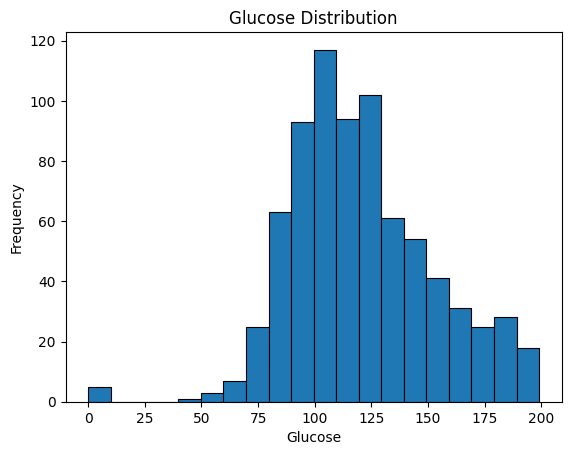

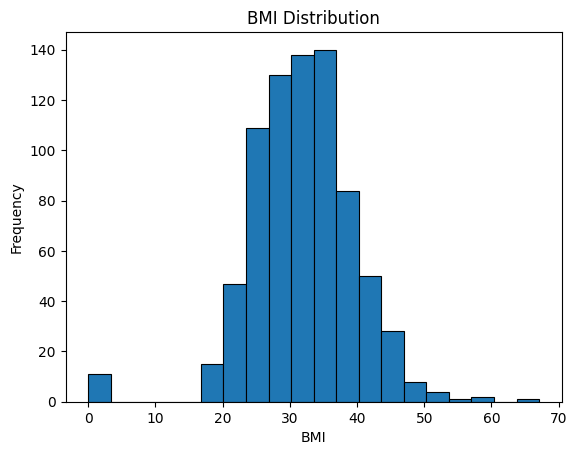

In [16]:
import matplotlib.pyplot as plt

# histogram for Glucose distribution
df["Glucose"].hist(bins=20, edgecolor="black", linewidth=0.8)

plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

# histogram for BMI distribution
df["BMI"].hist(bins=20, edgecolor="black", linewidth=0.8)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

### ***6.1 Bivariate Visualization 1: Glucose by Diabetes Outcome***

A boxplot is used to compare glucose measurements between patients with and without the diabetes outcome. Glucose is a continuous variable, while `Outcome` is a binary variable coded as 0 or 1.

This visualization helps determine whether glucose measurements differ between the two outcome groups and whether there are differences in the spread or potential outliers of glucose values.

***Interpretion:*** The boxplot shows that glucose measurements are generally higher among patients with a diabetes outcome of 1 compared with patients with an outcome of 0. The distributions also show some overlap between the two groups, indicating that glucose alone does not perfectly distinguish the outcome groups. This pattern suggests that glucose is an important characteristic to consider when examining diabetes risk in this dataset.

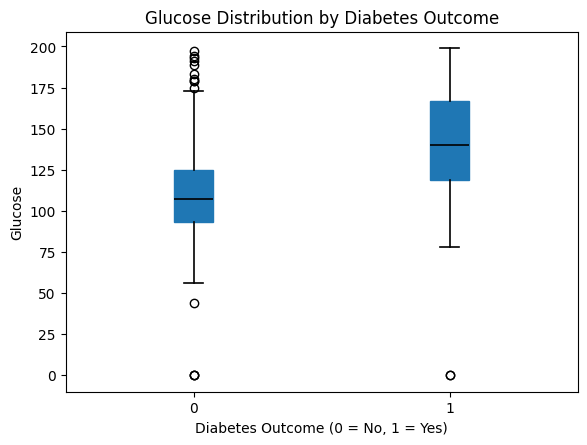

In [17]:
# compare glucose levels by diabetes outcome
box = df.boxplot(
    column="Glucose",
    by="Outcome",
    patch_artist=True
)

# fill box with a different color
colors = ["lightblue", "lightcoral"]

for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)

# make the median, whiskers, and caps black
for line in box.lines:
    line.set_color("black")
    line.set_linewidth(1.2)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.suptitle("")
plt.xlabel("Diabetes Outcome (0 = No, 1 = Yes)")
plt.ylabel("Glucose")
plt.grid(False)

plt.show()

### ***6.2 Bivariate Visualization 2: Glucose and BMI***

A scatterplot is used to examine the relationship between glucose and BMI because both variables are continuous measurements. The visualization helps identify whether higher BMI values tend to occur with higher glucose measurements and whether the relationship appears linear, weak, or highly variable in this dataset.

***Interpretion:*** The scatterplot shows a positive association between glucose and BMI, with higher glucose measurements generally occurring alongside higher BMI values. Most observations are concentrated between approximately 80 and 160 for glucose and 20 and 40 for BMI. However, the observations are widely dispersed, indicating substantial variability in BMI across glucose levels.

- Several observations have a BMI or glucose value of zero. Because these values may not represent plausible clinical measurements, they will be investigated during data preparation before further analysis.
- This visualization describes an association between glucose and BMI and does not establish that one variable causes changes in the other.



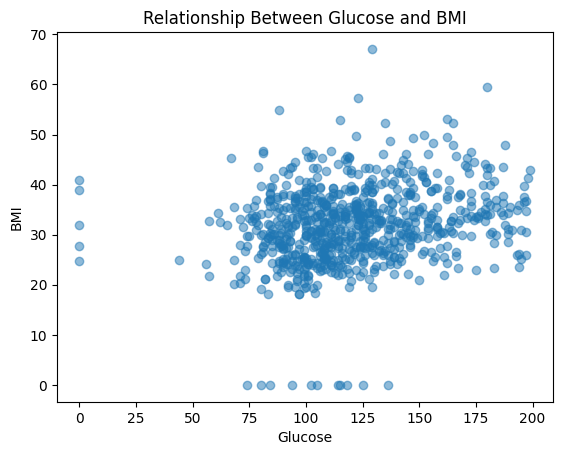

In [18]:
# Examine the relationship between glucose and BMI

plt.scatter(df["Glucose"], df["BMI"], alpha=0.5)

plt.title("Relationship Between Glucose and BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

### ***6.3 Correlation Matrix and Heatmap***

A correlation matrix is used to examine the relationships among the continuous and county-based numerical variable in the dataset. Spearman's rank correlation is used because several variables are not normally distributed and some variables contain extreme values. Spearman correlation evaluates the strength and direction of monotonic relationships using ranked values and is less sensitive to non-normality and extreme observations than Pearson correlation.

Correlation coefficients range from -1 to +1. Positive values indicate that higher values of one variable tend to be associated with higher values of another variable, while negative values indicate that higher values of one variable tend to be associated with lower values of another variable. Values closer to zero indicate weaker relationships. To note, the correlation analysis describes associations between variables and does not establish causation.

***Interpretation:***

- The Spearman correlation matrix shows that most relationships among the numerical variables are positive, although their strengths vary. The strongest association is between **Pregnancies and Age** ($\rho = 0.607$), indicating a relatively strong positive relationship in this dataset.

- A moderate positive association is observed between **Skin_Thickness and Insulin** ($\rho = 0.541$), while **Skin_Thickness and BMI** also show a moderate positive association ($\rho = 0.444$). **Age and D_BP** have a smaller positive association ($\rho = 0.351$).

- In relevance to the diabetes analysis, **Glucose and BMI** have a positive but relatively modest association ($\rho = 0.231$). This is consistent with the scatterplot, which showed that higher glucose measurements tend to occur with somewhat higher BMI values, but with substantial variability across observations.

- The remaining relationships are generally weak to modest, and the negative associations are relatively small. These findings describe associations between variables and do not establish causation. Additionally, the zero values identified during data validation may affect some of these relationships and will be investigated during data preparation.

In [19]:
# select numerical variables for the correlation analysis
numeric_vars = [
    "Pregnancies",
    "Glucose",
    "D_BP",
    "Skin_Thickness",
    "Insulin",
    "BMI",
    "Pedigree",
    "Age"
]

# calculate Spearman correlations
corr_matrix = df[numeric_vars].corr(method="spearman")

# display the correlationship matrix
corr_matrix

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age
Pregnancies,1.000000,0.130734,0.185127,-0.085222,-0.126723,0.000132,-0.043242,0.607216
Glucose,0.130734,1.000000,0.235191,0.060022,0.213206,0.231141,0.091293,0.285045
D_BP,0.185127,0.235191,1.000000,0.126486,-0.006771,0.292870,0.030046,0.350895
Skin_Thickness,-0.085222,0.060022,0.126486,1.000000,0.541000,0.443615,0.180390,-0.066795
Insulin,-0.126723,0.213206,-0.006771,0.541000,1.000000,0.192726,0.221150,-0.114213
BMI,0.000132,0.231141,0.292870,0.443615,0.192726,1.000000,0.141192,0.131186
Pedigree,-0.043242,0.091293,0.030046,0.180390,0.221150,0.141192,1.000000,0.042909
Age,0.607216,0.285045,0.350895,-0.066795,-0.114213,0.131186,0.042909,1.000000


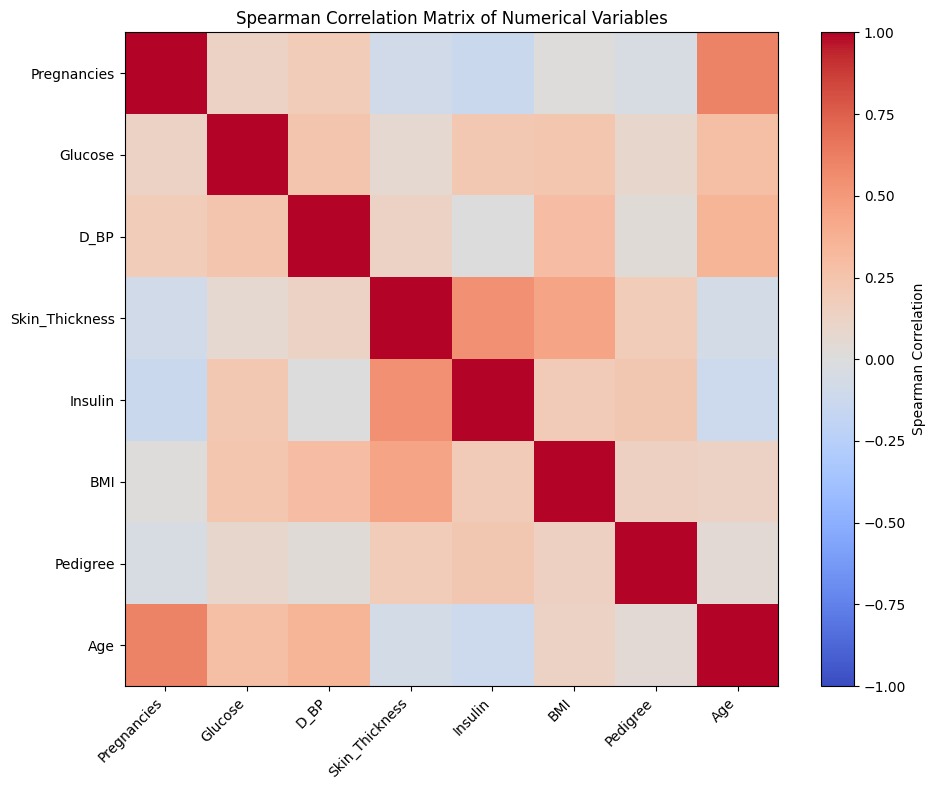

In [20]:
# Create a heatmap of the Spearman correlation matrix
plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Spearman Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Spearman Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

In [21]:
import numpy as np

# identify the strongest correlations between different variabels

corr_pairs = corr_matrix.where(
    ~np.triu(np.ones(corr_matrix.shape, dtype=bool))
).stack().sort_values(key=abs, ascending=False)

corr_pairs.head(10)

,,0
Age,Pregnancies,0.607216
Insulin,Skin_Thickness,0.541000
BMI,Skin_Thickness,0.443615
Age,D_BP,0.350895
BMI,D_BP,0.292870
Age,Glucose,0.285045
D_BP,Glucose,0.235191
BMI,Glucose,0.231141
Pedigree,Insulin,0.221150
Insulin,Glucose,0.213206


***** DATA SCIENCE DIRECTOR NOTE *****

The current visualizations primarily describe individual variables. Please add two appropriate bivariate visualizations to help the receiving data science team better understand relationships between variables in this dataset.

Select variables and visualization types that are appropriate for the data and relevant to the diabetes analysis. At least one of the visualizations should help us examine how a patient characteristic differs in relation to the diabetes outcome.

For each visualization:

• Include a clear, descriptive title and appropriately labeled axes.  
• Select a visualization type that is appropriate for the variables being examined.  
• Include a brief interpretation of the relationship or pattern shown.  
• Refer to the specific variables and findings from this dataset rather than providing a generic description of the visualization.

Please make sure the visualizations and accompanying interpretations are suitable for sharing with the data science team at our other clinical site.

***** DATA SCIENCE DIRECTOR NOTE *****

Please add a correlation matrix and heatmap for the appropriate numerical variables in this dataset. The visualization should be clearly labeled and easy to interpret. Select a correlation method that is appropriate for the variables and characteristics of the dataset; consider whether Pearson’s correlation, Spearman’s rank correlation, Phi_K, or another correlation method is most appropriate, and briefly justify your choice.

Include a brief narrative describing the most relevant relationships you observe. Your interpretation should identify the specific variables involved, describe the direction and relative strength of the relationships, and explain why selected relationships may be relevant to understanding this dataset. Remember that correlation does not establish causation.

## **7. Inferential Analysis**

The following analysis compares glucose values between the two outcome groups.

### ***7.1 Independent-Samples t-test***

An independent-samples t-test is used to determine whether the mean glucose level differs between patients with and without a diabetes outcome. In this analysis, glucose is the continuous variable and `Outcome` is the binary grouping variable, where 0 represents no diabetes outcome and 1 represents a diabetes outcome.

The independent-samples t-test evaluates whether the difference between the two group means is larger than would be expected from random variation. The test statistic is calculated as:

$$
t = \frac{\bar{x}_1 - \bar{x}_0}
{\sqrt{\frac{s_1^2}{n_1}+\frac{s_0^2}{n_0}}}
$$

where $\bar{x}_1$ and $\bar{x}_0$ are the mean glucose values for the two outcome groups, $s_1^2$ and $s_0^2$ are their variances, and $n_1$ and $n_0$ are their sample sizes.

The null hypothesis ($H_0$) states that the mean glucose level is the same for the two outcome groups. The alternative hypothesis ($H_A$) states that the mean glucose levels differ between the groups.

***Interpretion:*** The independent-samples t-test found a statistically significant difference in mean glucose levels between the two diabetes outcome groups ($t = -14.60$, $p < 0.001$). Patients with an outcome of 0 had a lower mean glucose level (approximately 109.98) than patients with an outcome of 1 (approximately 141.26).

- Because the p-value is substantially smaller than 0.05, the null hypothesis of equal mean glucose levels between the two groups is rejected. In this dataset, glucose levels therefore differ significantly between patients with and without a diabetes outcome.

- This result indicates an association between glucose level and diabetes outcome in this dataset; it does not establish that higher glucose causes diabetes.

In [22]:
from scipy.stats import ttest_ind

group_0 = df.loc[df["Outcome"] == 0, "Glucose"]
group_1 = df.loc[df["Outcome"] == 1, "Glucose"]

t_stat, p_value = ttest_ind(group_0, group_1)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -14.600060005973894
p-value: 8.935431645289912e-43


### ***7.2 Logistic regression***

Logistic regression is used to examine the association between glucose and the binary diabetes outcome. Because `Outcome` is coded as 0 (no diabetes) and 1 (diabetes), logistic regression is appropriate for modeling the probability of a diabetes outcome.

The logistic regression model is:

$$
\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1X
$$

where:

- $p$ = probability of a diabetes outcome
- $1-p$ = probability of no diabetes outcome
- $\frac{p}{1-p}$ = odds of a diabetes outcome
- $\beta_0$ = intercept
- $\beta_1$ = change in the log-odds of diabetes associated with a one-unit increase in glucose
- $X$ = glucose measurement

The analysis evaluates whether glucose is statistically associated with the odds of a diabetes outcome. The exponentiated coefficient, $e^{\beta_1}$, represents the odds ratio. An odds ratio greater than 1 indicates that higher glucose values are associated with higher odds of a diabetes outcome, while an odds ratio less than 1 indicates lower odds.

This analysis describes an association between glucose and diabetes outcome and does not establish causation.


***Interpretation:*** The logistic regression model showed a statistically significant positive association between glucose level and the diabetes outcome ($\beta_1 = 0.0379$, $p < 0.001$). The estimated odds ratio for glucose was **1.039** (95% CI: **1.032–1.045**).

- This means that for each one-unit increase in glucose, the estimated odds of a diabetes outcome increased by approximately **3.86%**. The 95% confidence interval does not include 1, providing evidence of a statistically significant association between glucose level and diabetes outcome in this dataset.

- The model successfully converged, indicating that the logistic regression estimation procedure reached a solution. The model's pseudo-$R^2$ was 0.186, indicating that glucose alone accounts for some, but not all, of the variation in the diabetes outcome.

- Again, this analysis identifies an association between glucose and diabetes outcome and does not establish that higher glucose causes diabetes. Other patient characteristics and risk factors may also contribute to the diabetes outcome.

In [23]:
import statsmodels.api as sm

# define predictor and outcome
X = df[["Glucose"]]
y = df["Outcome"]

# add intercept
X = sm.add_constant(X)

# fit logistic regression model
logistic_model = sm.Logit(y, X).fit()

# print model summary
print(logistic_model.summary())

# calculate the odds ratio for Glucose
odds_ratio = np.exp(logistic_model.params["Glucose"])

# Convert the odds ratio to a percentage change in odds
percent_change = (odds_ratio - 1) * 100

print("Percent change in odds per 1-unit increase in Glucose:",
      round(percent_change, 2), "%")

# calculate the 95% confidence interval for the odds ratio
odds_ratio_ci = np.exp(logistic_model.conf_int().loc["Glucose"])

print("95% CI for odds ratio:", odds_ratio_ci.values)

Optimization terminated successfully.
         Current function value: 0.526510
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      766
Method:                           MLE   Df Model:                            1
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                  0.1860
Time:                        03:59:49   Log-Likelihood:                -404.36
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 4.418e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3501      0.421    -12.713      0.000      -6.175      -4.525
Glucose        0.0379      0.

***** DATA SCIENCE DIRECTOR NOTE *****

Please include one additional inferential statistical method that is appropriate for the research questions and variables in this dataset.

For the method you select:

• State the purpose of the analysis.  
• Include the mathematical notation for the method.  
• Provide a brief description of what the method evaluates.  
• Report and interpret the result.  
• Make the explanation specific to the variables and diabetes outcome represented in this dataset.

Please ensure that all mathematical notation renders correctly in the final notebook.

## **8. Data, Statistics, and the Machine Learning Workflow**

### ***8.1 Formalizing the Statistical and Machine Learning Problem***

The diabetes dataset contains **768 observations** and **9 variables**. The analysis uses eight patient characteristics as predictor variables and a binary diabetes outcome as the target variable.

The dataset can be represented as:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{p},
\qquad
y_i \in \{0,1\}
$$

where:

- $\mathcal{D}$ denotes the complete dataset.
- $n = 768$ is the total number of observations.
- $i$ represents the index of an individual observation, where $i = 1,2,\ldots,768$.
- $x_i$ is the feature vector containing the predictor variables for observation $i$.
- $p = 8$ is the total number of predictor variables.
- $\mathbb{R}^{p}$ represents the 8-dimensional feature space.
- $y_i$ is the diabetes outcome for observation $i$.
- $y_i = 0$ represents no diabetes outcome.
- $y_i = 1$ represents a diabetes outcome.

The eight predictor variables used to represent each observation are:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies}_i \\
\text{Glucose}_i \\
\text{D_BP}_i \\
\text{Skin_Thickness}_i \\
\text{Insulin}_i \\
\text{BMI}_i \\
\text{Pedigree}_i \\
\text{Age}_i
\end{bmatrix}
$$

and the target variable is:

$$
y_i = \text{Outcome}_i
$$

Thus, each observation contains information about a patient's pregnancies, glucose level, diastolic blood pressure, skin thickness, insulin level, BMI, diabetes pedigree function, and age. The corresponding `Outcome` variable identifies whether the observation belongs to the no-diabetes outcome group (0) or diabetes outcome group (1).

Because the target variable has two possible values, the diabetes outcome represents a **binary classification problem**. In supervised machine learning, the objective is to use the predictor variables to estimate a prediction function:
$$
\hat{f}: \mathbb{R}^{8} \rightarrow \{0,1\}
$$

where $\hat{f}$ represents the estimated prediction function learned from the data.

The function $\hat{f}(\cdot)$ maps the eight predictor variables for an observation to a predicted diabetes outcome. For a new observation with values for `Pregnancies`, `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, `BMI`, `Pedigree`, and `Age`, the model can estimate whether the observation belongs to the 0 or 1 outcome group.

The statistical analyses in this notebook first examine the characteristics and relationships within the dataset. Inferential analyses then evaluate the association between glucose and the diabetes outcome using an independent-samples t-test and logistic regression. If machine learning models are subsequently applied, the predictor variables are used to estimate diabetes outcomes for observations not used to train the model.

***** DATA SCIENCE DIRECTOR NOTE *****

The mathematical notation in this section is rendering correctly, but this content appears to have been adapted from a generic template and has not been fully customized for our analysis.

Please revise this section so that it accurately represents the dataset and analytical workflow used in this notebook. In particular, replace generic placeholders such as var1, var2, and target with the actual variable names used in the dataset and verify that the stated number of predictor variables (p) is correct.

Also review the surrounding narrative and mathematical notation for any other generic language that should be made specific to this analysis. A member of the data science team at our other clinical site should be able to read this section and understand exactly how the dataset used in this notebook is represented as a statistical and machine learning problem.

## **9. Reproducibility Check**

Some exploratory steps in this notebook use random sampling. Without a fixed random seed, the selected observations and bootstrap estimates can change each time the notebook is executed.

To ensure reproducibility, a fixed random seed (`random_state = 27`) is used for all random sampling operations in this section. This allows another data scientist to rerun the notebook and obtain the same sample and bootstrap estimate, assuming the underlying dataset remains unchanged.

The participant sample is used only for review and does not affect the statistical analyses. The bootstrap estimate provides an exploratory estimate of the mean BMI based on sampling with replacement.

***Interpretation:*** The random sampling procedures use a fixed random seed (`random_state = 27`). This ensures that the same eight observations are selected and the same bootstrap sample is generated each time the notebook is executed, provided that the underlying dataset remains unchanged.

- The reproducible bootstrap estimate of the mean BMI is **31.46**.

In [24]:
# set a random seed so random operations produce the same results each time
random_state = 27

# A small participant sample used during review
df.sample(8, random_state=random_state)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
223,7,142,60,33,190,28.8,0.687,61,0
461,1,71,62,0,0,21.8,0.416,26,0
175,8,179,72,42,130,32.7,0.719,36,1
636,5,104,74,0,0,28.8,0.153,48,0
349,5,0,80,32,0,41.0,0.346,37,1
637,2,94,76,18,66,31.6,0.649,23,0
115,4,146,92,0,0,31.2,0.539,61,1
678,3,121,52,0,0,36.0,0.127,25,1


In [25]:
# Bootstrap estimate used during exploratory review
bootstrap_mean_bmi = (
    df["BMI"]
    .sample(n=len(df), replace=True, random_state=random_state)
    .mean())

print("Bootstrap mean BMI:", bootstrap_mean_bmi)

Bootstrap mean BMI: 31.46302083333333


***** DATA SCIENCE DIRECTOR NOTE *****

I was able to run parts of this notebook, but some results changed when I executed it again. Please investigate and make sure results that should be reproducible remain consistent across executions.

## **Results and Conclusions**

Add a concise summary of the major analytical findings and any important limitations.

### ***Results***

The dataset included **768 observations and 9 variables**, including eight patient characteristics and a binary diabetes outcome. Descriptive statistics showed substantial variation across patient characteristics, including glucose, BMI, blood pressure, insulin, and age.

The visualizations showed that **glucose levels were generally higher among patients with a diabetes outcome of 1** compared with those with an outcome of 0. The scatterplot also showed a positive but relatively modest association between glucose and BMI.

The Spearman correlation analysis identified the strongest relationships between **Pregnancies and Age** ($\rho = 0.607$) and **Skin_Thickness and Insulin** ($\rho = 0.541$). The association between **Glucose and BMI** was positive but modest ($\rho = 0.231$).

The independent-samples t-test found a statistically significant difference in mean glucose levels between the two outcome groups ($t = -14.60$, $p < 0.001$). Mean glucose was approximately **109.98** among observations with an outcome of 0 and **141.26** among observations with an outcome of 1.

The logistic regression analysis also identified a statistically significant positive association between glucose and diabetes outcome ($\beta_1 = 0.0379$, $p < 0.001$). The estimated odds ratio was **1.039** (95% CI: **1.032–1.045**), indicating that each one-unit increase in glucose was associated with approximately **3.86% higher odds** of a diabetes outcome.

### ***Conclusions***

Overall, the analyses identified a consistent association between **glucose level and diabetes outcome** in this dataset. Higher glucose levels were observed among patients with a diabetes outcome, and both the t-test and logistic regression provided statistical evidence of this difference and association.

### ***Limitations***

Several limitations should be considered when interpreting these findings:

- The analysis examines **associations rather than causation**.
- The logistic regression model included glucose as the predictor and therefore does not account for other patient characteristics that may be associated with diabetes outcome.
- Several variables contained **zero values that may not represent clinically plausible measurements**, particularly glucose, blood pressure, skin thickness, insulin, and BMI. These values should be investigated during data preparation.
- The dataset contains **768 observations**, which may limit how broadly the findings can be generalized beyond the population represented by this dataset.
- The results depend on the quality and accuracy of the underlying dataset and its variable definitions.

***** DATA SCIENCE DIRECTOR NOTE *****

Before this project is shared, please review the organization of the entire notebook. I should be able to follow the analysis from setup, data source and validation through preparation, analysis, results, and conclusions without having to determine the correct execution order.

Use modular functions where they improve clarity, maintainability, or reproducibility. Not every code block needs to become a function.

The final notebook should pass a clean Restart session and run all test.

Once you have addressed all director notes throughout the notebook, remove all DATA SCIENCE DIRECTOR NOTE references and instructions before submitting the final version. The notebook shared with the receiving data science team should be a clean, professional analytical workflow and should not contain internal review comments.